<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Solution to Exercise Set 3, Exercise 1 - A <span style="color:red">Convolutional</span> Neural Network to Classify n-Gons

This notebook gives the first example of a *convolutional* neural network for the same data as before: **triangles, quadrilaterals, pentagons and hexagons.**

Step through and run all cells up to **Visualize the Filters** at the end. Follow the instructions there.

On your way, try to read and understand as much of the code as possible.

Remember that you can split cells with `CTRL` + `shift` + `-` anytime you want to check an intermediate result. Often that's the easiest way to understand what's going on.

(Don't worry to mess up the code, there is a way to revert back to default on request.)

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pickle  # to load 'pickled' numpy arrays (serialized, compressed)

In [2]:
# load image data as numpy arrays (generated with a separate script available on request)
# Pickling is a way to store datastructures on a drive - or cucumbers in a glass.
# load training data
with open("../../../data/ngons/ngon_train.pkl", "rb") as f:
    Xtrain, ytrain_class = pickle.load(f)
# load test data
with open("../../../data/ngons/ngon_test.pkl", "rb") as f:
    Xtest, ytest_class = pickle.load(f)
    
Xtrain = np.expand_dims(Xtrain, -1)
Xtest = np.expand_dims(Xtest, -1)

num_train = Xtrain.shape[0]
num_test = Xtest.shape[0]
height = Xtrain.shape[1]
width = Xtrain.shape[2]
img_size_flat = width * height

print("Images are", width, "by", height, "pixels and have", Xtrain.shape[3], "color channel.")

num_classes = 4 # 0, 1, 2, 3 for 3-, 4-, 5-, 6-gons

# one-hot encode output classes
ytrain = np.eye(num_classes, dtype=float)[ytrain_class]
ytest = np.eye(num_classes, dtype=float)[ytest_class]
print("Fraction of classes:", np.mean(ytrain, axis=0)) # close to 1/4 each

# normalize input to [0,1]
Xtrain = Xtrain / 255.
Xtest = Xtest / 255.

print("Size of training set is", num_train, ", size of test set is", num_test)

# Number of classes
num_classes = 4 # 0, 1, 2, 3 for 3, ..., 6 gons


Images are 32 by 32 pixels and have 1 color channel.
Fraction of classes: [0.2567 0.2409 0.2502 0.2522]
Size of training set is 10000 , size of test set is 2000


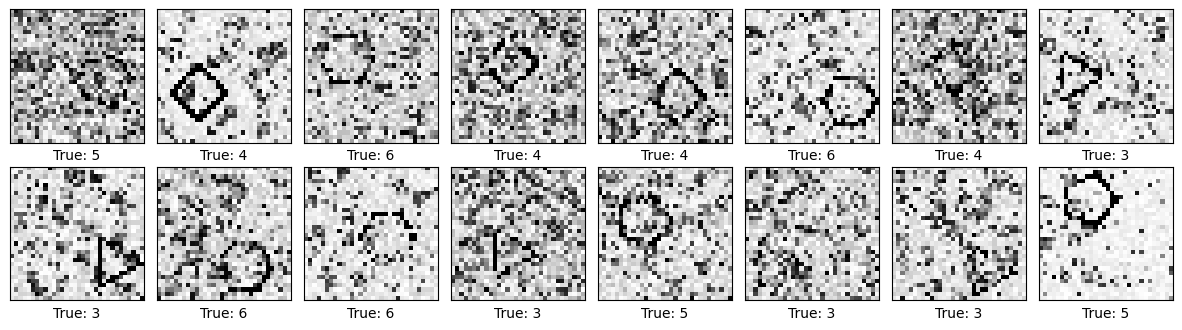

In [3]:
# Function to plot 8 images in a 2x4 grid, and writing the true and predicted classes below each image.
def plot_images(images, class_true, class_pred = None):
    """ Plot 16 (sample) images with their true and predicted classes"""
    assert len(images) == len(class_true) == 16

    # Create figure with sub-plots.
    fig, axes = plt.subplots(2, 8, figsize=(15, 4))
    fig.subplots_adjust(hspace=0.05, wspace=0.1)

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], interpolation = 'none', cmap = 'binary') # plot image

        # display also true and predicted classes
        if class_pred is None:
            xlabel = "True: {0}".format(3 + class_true[i])
        else:
            xlabel = "True: {0}, Pred: {1}".format(3 + class_true[i], 3 + class_pred[i])

        ax.set_xlabel(xlabel)

        # remove ticks from the plot
        ax.set_xticks([])
        ax.set_yticks([])


plot_images(Xtrain[0:16], ytrain_class[0:16])

## Create a Convolutional Neural Network Model


<img src="../../cnn-ngon.png" alt="cnn architecture" width="800"/>



In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# define the CNN model
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=8, kernel_size=(13, 13)),
    nn.MaxPool2d(kernel_size=(20, 20)),
    nn.Conv2d(in_channels=8, out_channels=4, kernel_size=(1, 1)),
    nn.Softmax(dim=1),  # Softmax across channel dimension
    nn.Flatten()
).to(device)
print (model)

Sequential(
  (0): Conv2d(1, 8, kernel_size=(13, 13), stride=(1, 1))
  (1): MaxPool2d(kernel_size=(20, 20), stride=(20, 20), padding=0, dilation=1, ceil_mode=False)
  (2): Conv2d(8, 4, kernel_size=(1, 1), stride=(1, 1))
  (3): Softmax(dim=1)
  (4): Flatten(start_dim=1, end_dim=-1)
)


In [5]:
# Convert data to PyTorch tensors, channel dimension (size 1) must go to position 1
Xtrain_torch = torch.tensor(Xtrain, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
ytrain_torch = torch.tensor(ytrain, dtype=torch.float32).to(device)
Xtest_torch = torch.tensor(Xtest, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
ytest_torch = torch.tensor(ytest, dtype=torch.float32).to(device)
print (Xtrain_torch.shape, ytrain_torch.shape)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()  # Handles one-hot internally
optimizer = optim.Adam(model.parameters(), lr=0.001)

torch.Size([10000, 1, 32, 32]) torch.Size([10000, 4])


In [6]:
# Training loop (manual implementation to match Keras fit)
epochs = 20
batch_size = 64
val_split = 0.2
num_val = int(num_train * val_split)
num_train_split = num_train - num_val

history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Shuffle training data
    perm = torch.randperm(num_train_split)
    Xtrain_split = Xtrain_torch[:num_train_split][perm]
    ytrain_split = ytrain_torch[:num_train_split][perm]
    
    for i in range(0, num_train_split, batch_size):
        batch_X = Xtrain_split[i:i + batch_size]
        batch_y = ytrain_split[i:i + batch_size]
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, torch.argmax(batch_y, dim=1))  # Convert one-hot to class indices
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        _, labels = torch.max(batch_y, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / (num_train_split // batch_size)
    epoch_acc = correct / total
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_X = Xtrain_torch[num_train_split:]
        val_y = ytrain_torch[num_train_split:]
        val_outputs = model(val_X)
        val_loss = criterion(val_outputs, torch.argmax(val_y, dim=1))
        _, val_pred = torch.max(val_outputs, 1)
        _, val_labels = torch.max(val_y, 1)
        val_acc = (val_pred == val_labels).sum().item() / val_labels.size(0)
    
    history['val_loss'].append(val_loss.item())
    history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

Epoch 1/20, Loss: 1.3340, Accuracy: 0.4250, Val Loss: 1.2275, Val Accuracy: 0.7280
Epoch 2/20, Loss: 1.1085, Accuracy: 0.7446, Val Loss: 1.0314, Val Accuracy: 0.7405
Epoch 3/20, Loss: 0.9656, Accuracy: 0.9127, Val Loss: 0.9080, Val Accuracy: 0.9770
Epoch 4/20, Loss: 0.8637, Accuracy: 0.9809, Val Loss: 0.8390, Val Accuracy: 0.9865
Epoch 5/20, Loss: 0.8189, Accuracy: 0.9865, Val Loss: 0.8115, Val Accuracy: 0.9905
Epoch 6/20, Loss: 0.7983, Accuracy: 0.9900, Val Loss: 0.7966, Val Accuracy: 0.9860
Epoch 7/20, Loss: 0.7868, Accuracy: 0.9910, Val Loss: 0.7874, Val Accuracy: 0.9915
Epoch 8/20, Loss: 0.7793, Accuracy: 0.9926, Val Loss: 0.7821, Val Accuracy: 0.9875
Epoch 9/20, Loss: 0.7740, Accuracy: 0.9936, Val Loss: 0.7766, Val Accuracy: 0.9900
Epoch 10/20, Loss: 0.7701, Accuracy: 0.9945, Val Loss: 0.7735, Val Accuracy: 0.9915
Epoch 11/20, Loss: 0.7672, Accuracy: 0.9952, Val Loss: 0.7705, Val Accuracy: 0.9920
Epoch 12/20, Loss: 0.7646, Accuracy: 0.9954, Val Loss: 0.7696, Val Accuracy: 0.9900
E

In [7]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    test_outputs = model(Xtest_torch)
    test_loss = criterion(test_outputs, torch.argmax(ytest_torch, dim=1))
    _, test_pred = torch.max(test_outputs, 1)
    _, test_labels = torch.max(ytest_torch, dim=1)
    test_acc = (test_pred == test_labels).sum().item() / test_labels.size(0)

print("Loss on test set:", test_loss.item(), "\nAccuracy on test set:", test_acc)

Loss on test set: 0.7575775980949402 
Accuracy on test set: 0.995


### Plot the training history

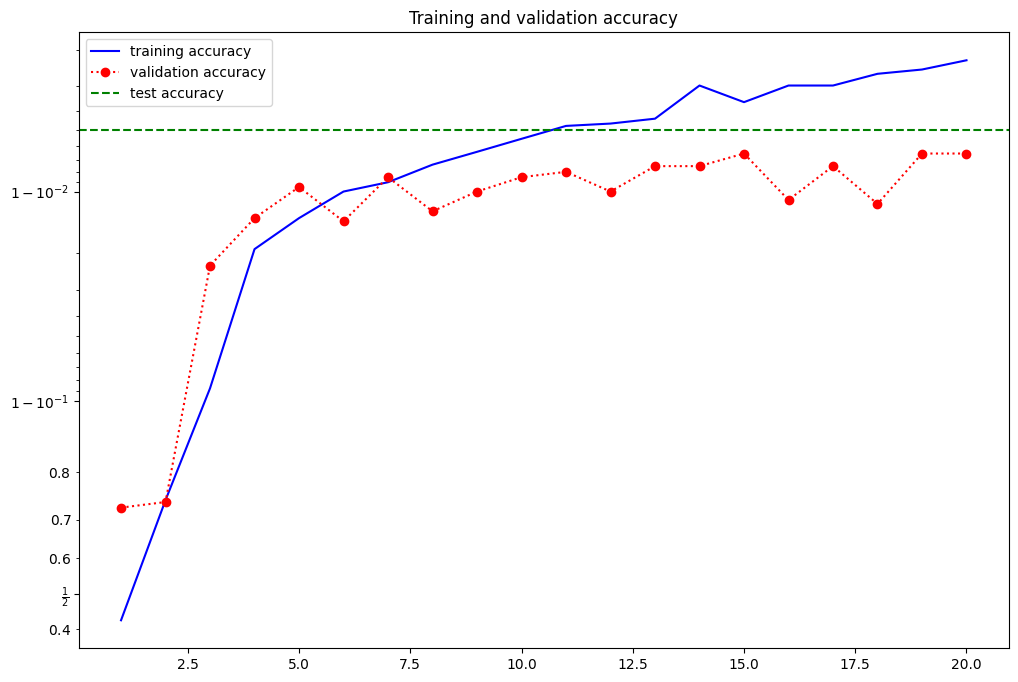

In [8]:
fig, ax = plt.subplots(figsize = (12, 8))

ax.set_title('Training and validation accuracy')

acc = history['accuracy']
val_acc = history['val_accuracy']
epochs = range(1, len(acc) + 1)
ax.set_yscale('logit')


ax.plot(epochs, acc, color = "blue", label = "training accuracy")
ax.plot(epochs, val_acc, "o:", color = "red", label = "validation accuracy")
ax.axhline(y = test_acc, color = "green", linestyle = "--", label = "test accuracy")

ax.legend();

From above plot we see that the model classifies training data siginifantly better than test data (overfit). It indicates that a model with fewer parameters or regularization could be better.

# Make and Examine Predictions

Predicted class probabilities for 3, 4, 5, 6 for the first 16 images:
 [[0.    0.998 0.002 0.001]
 [0.    0.    0.131 0.868]
 [0.999 0.001 0.    0.001]
 [0.    0.    0.    1.   ]
 [0.    1.    0.    0.   ]
 [0.    1.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    1.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    0.003 0.993 0.004]
 [1.    0.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [1.    0.    0.    0.   ]
 [0.    1.    0.    0.   ]
 [0.01  0.814 0.109 0.067]
 [0.998 0.    0.002 0.   ]]


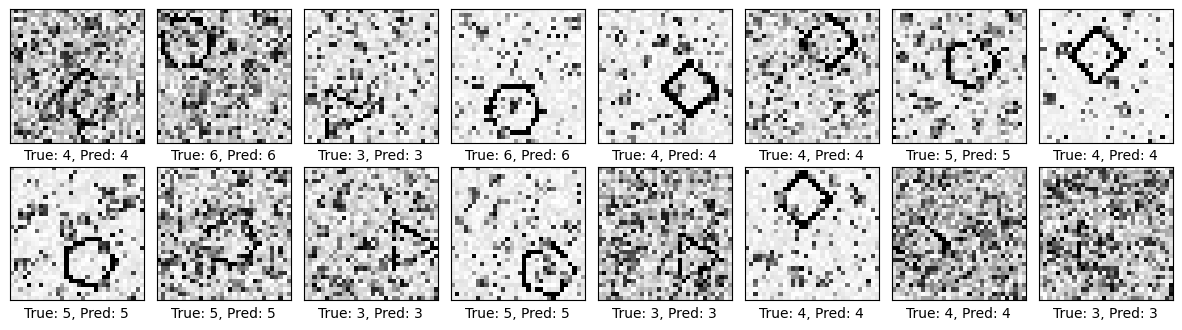

In [9]:
ytest_pred = model(Xtest_torch).cpu().detach()
print("Predicted class probabilities for 3, 4, 5, 6 for the first 16 images:\n", ytest_pred[0:16].numpy().round(3))

ytest_predclass = np.argmax(ytest_pred, axis = 1)
plot_images(Xtest[0:16], ytest_class[0:16], ytest_predclass[0:16])

# Visualize the Filters
Your task is to create a figure with 8 subplots (axes), one for each filter from the first layer.
Each subplot is a visualization of a $13 \times 13$ array of real numbers. This helps to understand, what patterns the filter respond to, at least in this very simple example.

In [10]:
# obtain the tensor of convolutional filters from the first layer 
Theta0 = model[0].weight.data.cpu().numpy()  # Access first Conv2d layer's weights
print(Theta0.shape)
# print the third filter as numbers
np.set_printoptions(linewidth = 100)
print(Theta0[2, 0, :, :].round(3))

(8, 1, 13, 13)
[[-0.1   -0.062 -0.067 -0.094 -0.155 -0.033 -0.135  0.141  0.645 -0.106 -0.156 -0.02   0.071]
 [ 0.005 -0.022 -0.093 -0.269 -0.256 -0.265  0.43   0.479  0.399  0.423 -0.253 -0.062  0.082]
 [-0.089 -0.12   0.472  0.331  0.429  0.57   0.014 -0.134 -0.067  0.522  0.382 -0.117 -0.12 ]
 [-0.042  0.5    0.334 -0.182  0.085  0.083 -0.05  -0.003 -0.052 -0.096  0.42   0.372 -0.183]
 [-0.086  0.276 -0.372  0.14   0.112 -0.126 -0.183 -0.062 -0.036 -0.009 -0.093  0.377 -0.166]
 [-0.221  0.157  0.038  0.137 -0.002 -0.036 -0.011  0.073  0.024 -0.046 -0.026 -0.197  0.349]
 [-0.441  0.433  0.083 -0.02  -0.052  0.067 -0.036 -0.032  0.049 -0.111 -0.015 -0.097  0.235]
 [-0.368  0.431  0.024 -0.053 -0.097  0.02   0.042 -0.101  0.007 -0.006 -0.028 -0.1    0.161]
 [-0.11   0.179  0.016  0.067 -0.079 -0.032  0.042  0.023 -0.115 -0.083 -0.111 -0.306  0.41 ]
 [-0.042  0.258 -0.383  0.084  0.127 -0.046 -0.116  0.015  0.04  -0.123 -0.11   0.326 -0.178]
 [-0.006  0.347  0.271 -0.112  0.074  0.016 -

Tips: 
 - [plt.imshow](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.imshow.html) automatically scales the pixel numbers to be between 0 and 1 using the minimum and maximum pixel value of the image (i.e. the brightest pixel of each image is always white and the darkest is always black).

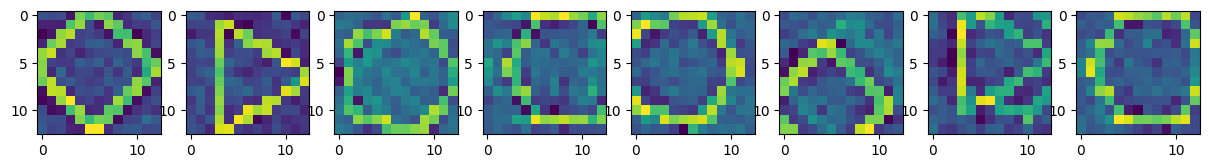

In [11]:
# YOUR CODE HERE to create a plot of the filters
_, axes = plt.subplots(1, 8, figsize = (15, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(Theta0[i, 0, :, :])

If you are done and you've got yourself a GPU node, why not adjust the model architecture above a little bit and see if you can do something about the overfitting?